# Mathematical Symbol Feature Extraction:

## Tasks:

- Extraction of HOG, LBP and RAW images/pixels features from Mathematical Symbol dataset and classification using Support Vector Machine (SVM)

- Extraction of HOG, LBP and RAW images/pixels features from Mathematical Symbol dataset and classification using Artificial Neural Network (ANN)


In [ ]:
# Import the required packages
import os
import cv2
import random
import warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from skimage import feature
from sklearn.svm import SVC
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

###  Mount the Google Drive to access the data

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### Dataset preparation

In [ ]:
# Load dataset from directory
DATASET_PATH = "/content/gdrive/MyDrive/42028 assessments/assessment 1/dataset_42028assg1_25077696"

# Initialize lists for images and labels
X_raw, y_labels = [], []

# Read images from each class folder
categories = sorted(os.listdir(DATASET_PATH))
for category in categories:
    category_path = os.path.join(DATASET_PATH, category)
    if os.path.isdir(category_path):
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, (64, 64))  # Ensure consistency
            X_raw.append(image.flatten())  # Flatten image for ANN input
            y_labels.append(category)

X_raw = np.array(X_raw)
y_labels = np.array(y_labels)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

# Normalize raw pixel values
X_raw = X_raw.astype("float32") / 255.0  # Normalize between 0-1

### Visualization of Dataset

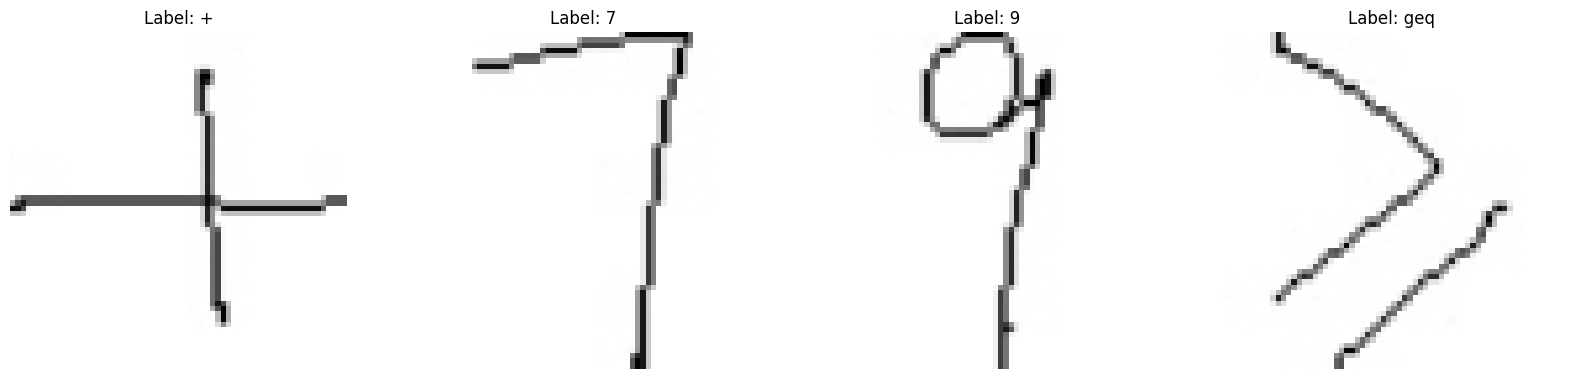

In [ ]:
# view few images and print its corresponding label
img_indices = [10, 1000, 2000, 3000]  # Example indices, adjust based on dataset size
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, img_index in zip(axes, img_indices):
    ax.imshow(X_raw[img_index].reshape(64, 64), cmap='gray')  # Reshape back to 2D for display
    ax.title.set_text(f'Label: {y_labels[img_index]}')
    ax.axis('off')

plt.show()


**Feature extraction for the whole training dataset**

In [ ]:
# HoG & LBP & RAW feature extraction
X_hog, X_lbp = [], []

for image in X_raw.reshape(-1, 64, 64):
    # Extract HoG features
    hog_features = feature.hog(image, pixels_per_cell=(8, 8),
                               cells_per_block=(2, 2), transform_sqrt=True,
                               block_norm="L2-Hys")
    X_hog.append(hog_features)

    # Extract LBP features
    lbp_features = feature.local_binary_pattern(image, P=8, R=1, method="uniform")
    X_lbp.append(lbp_features.flatten())

X_hog = np.array(X_hog)
X_lbp = np.array(X_lbp)
X_raw = X_raw.reshape(X_raw.shape[0], -1)
# Print feature shapes
print(f"HoG Feature Shape: {X_hog.shape}")
print(f"LBP Feature Shape: {X_lbp.shape}")
print(f"Raw Pixels Shape: {X_raw.shape}")

HoG Feature Shape: (5000, 1764)
LBP Feature Shape: (5000, 4096)
Raw Pixels Shape: (5000, 4096)


###  Training SVM withe HOG, LBP and Raw Pixels
- Evaluation of trained SVM model for all
- plot the confusion matrix for all


Training SVM on HoG features...
Accuracy (HoG - SVM): 0.9830


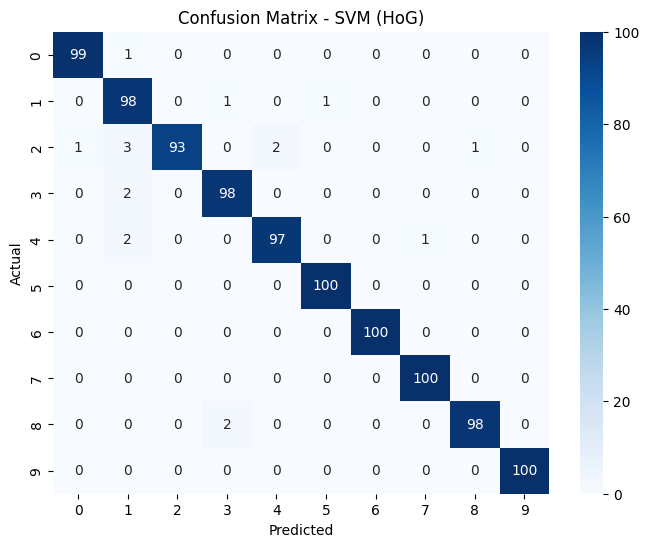


Training SVM on LBP features...
Accuracy (LBP - SVM): 0.9490


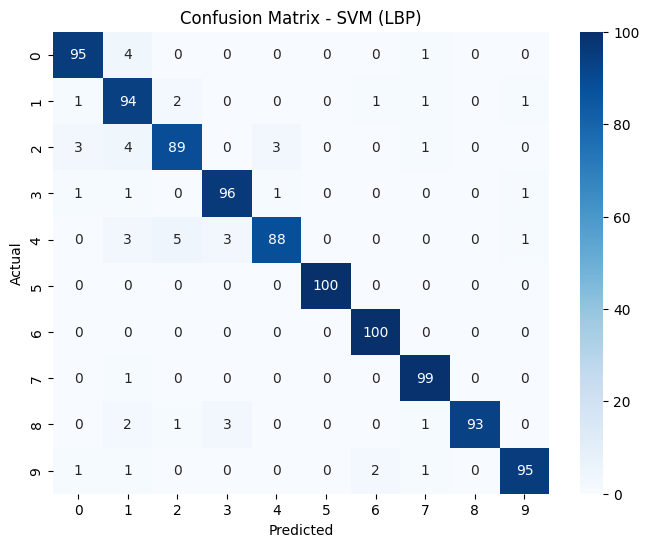


Training SVM on Raw Pixels features...
Accuracy (Raw Pixels - SVM): 0.9510


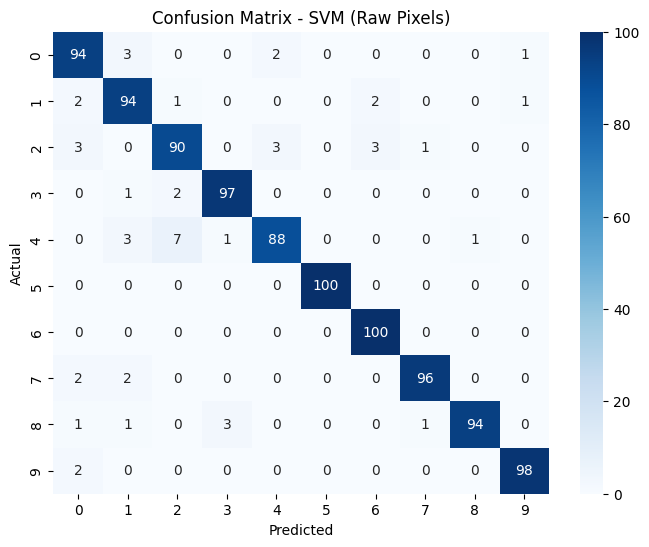

In [ ]:
#SVM
feature_sets = {"HoG": X_hog, "LBP": X_lbp, "Raw Pixels": X_raw}
svm_models = {}

for feature_name, X_feature in feature_sets.items():
    print(f"\nTraining SVM on {feature_name} features...")

    X_train, X_test, y_train, y_test = train_test_split(
        X_feature, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # Train SVM
    model_svm = SVC(kernel="linear")
    model_svm.fit(X_train, y_train)
    y_pred = model_svm.predict(X_test)

    # Save model & Print accuracy
    svm_models[feature_name] = model_svm
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({feature_name} - SVM): {acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix - SVM ({feature_name})')
    plt.show()

###  Training ANN withe HOG, LBP and Raw Pixels
- Evaluation of trained ANN model for all
- plot the confusion matrix for all


Training ANN on HoG features...
Accuracy (HoG - ANN): 0.9740


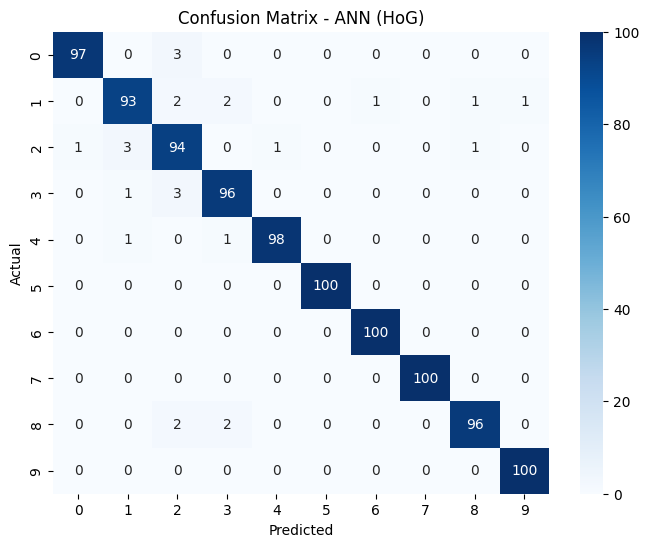


Training ANN on LBP features...
Accuracy (LBP - ANN): 0.8800


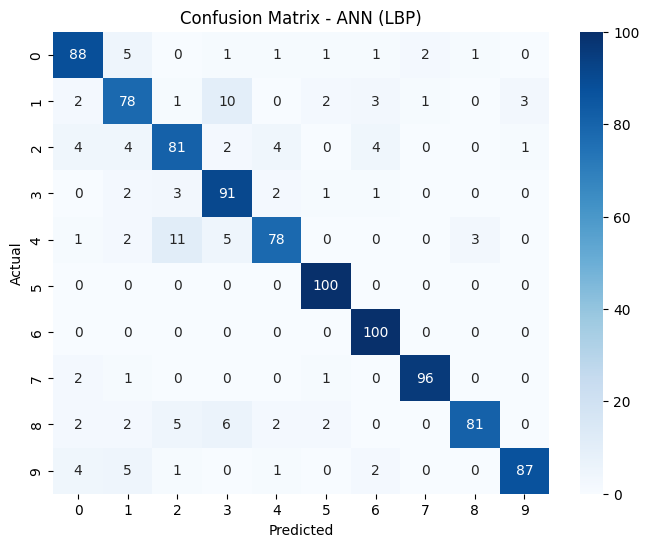


Training ANN on Raw Pixels features...
Accuracy (Raw Pixels - ANN): 0.9380


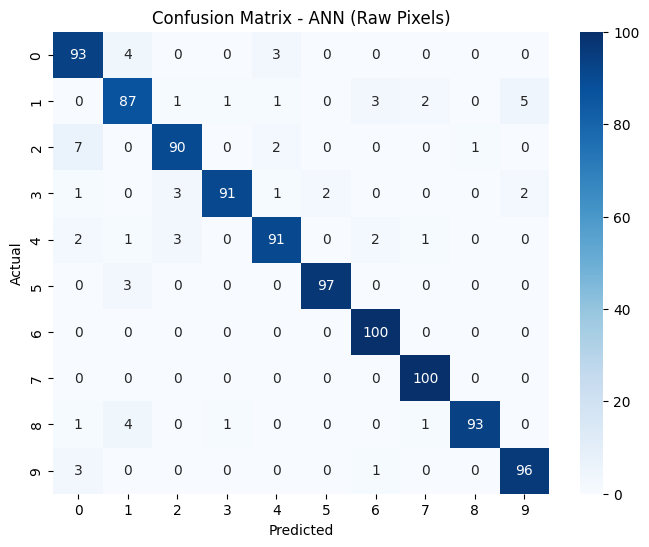

In [ ]:
#ANN
ann_models = {}

# Train ANN for each feature type
for feature_name, X_feature in feature_sets.items():
    print(f"\nTraining ANN on {feature_name} features...")

    X_train, X_test, y_train, y_test = train_test_split(
        X_feature, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    y_train_enc = to_categorical(y_train)
    y_test_enc = to_categorical(y_test)

    # Define ANN Model
    model_ann = Sequential([
        Input(shape=(X_train.shape[1],)),  # Define the input shape explicitly here
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(y_train_enc.shape[1], activation="softmax")
    ])

    model_ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

    # Train the model silently
    model_ann.fit(X_train, y_train_enc, epochs=100, batch_size=32, verbose=0)

    # Save model & Print accuracy
    y_pred_ann = np.argmax(model_ann.predict(X_test, verbose=0), axis=1)  # Set verbose=0 in predict too
    ann_models[feature_name] = model_ann
    accuracy = accuracy_score(y_test, y_pred_ann)
    print(f"Accuracy ({feature_name} - ANN): {accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_ann)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix - ANN ({feature_name})')
    plt.show()


# Display some classification result on test samples

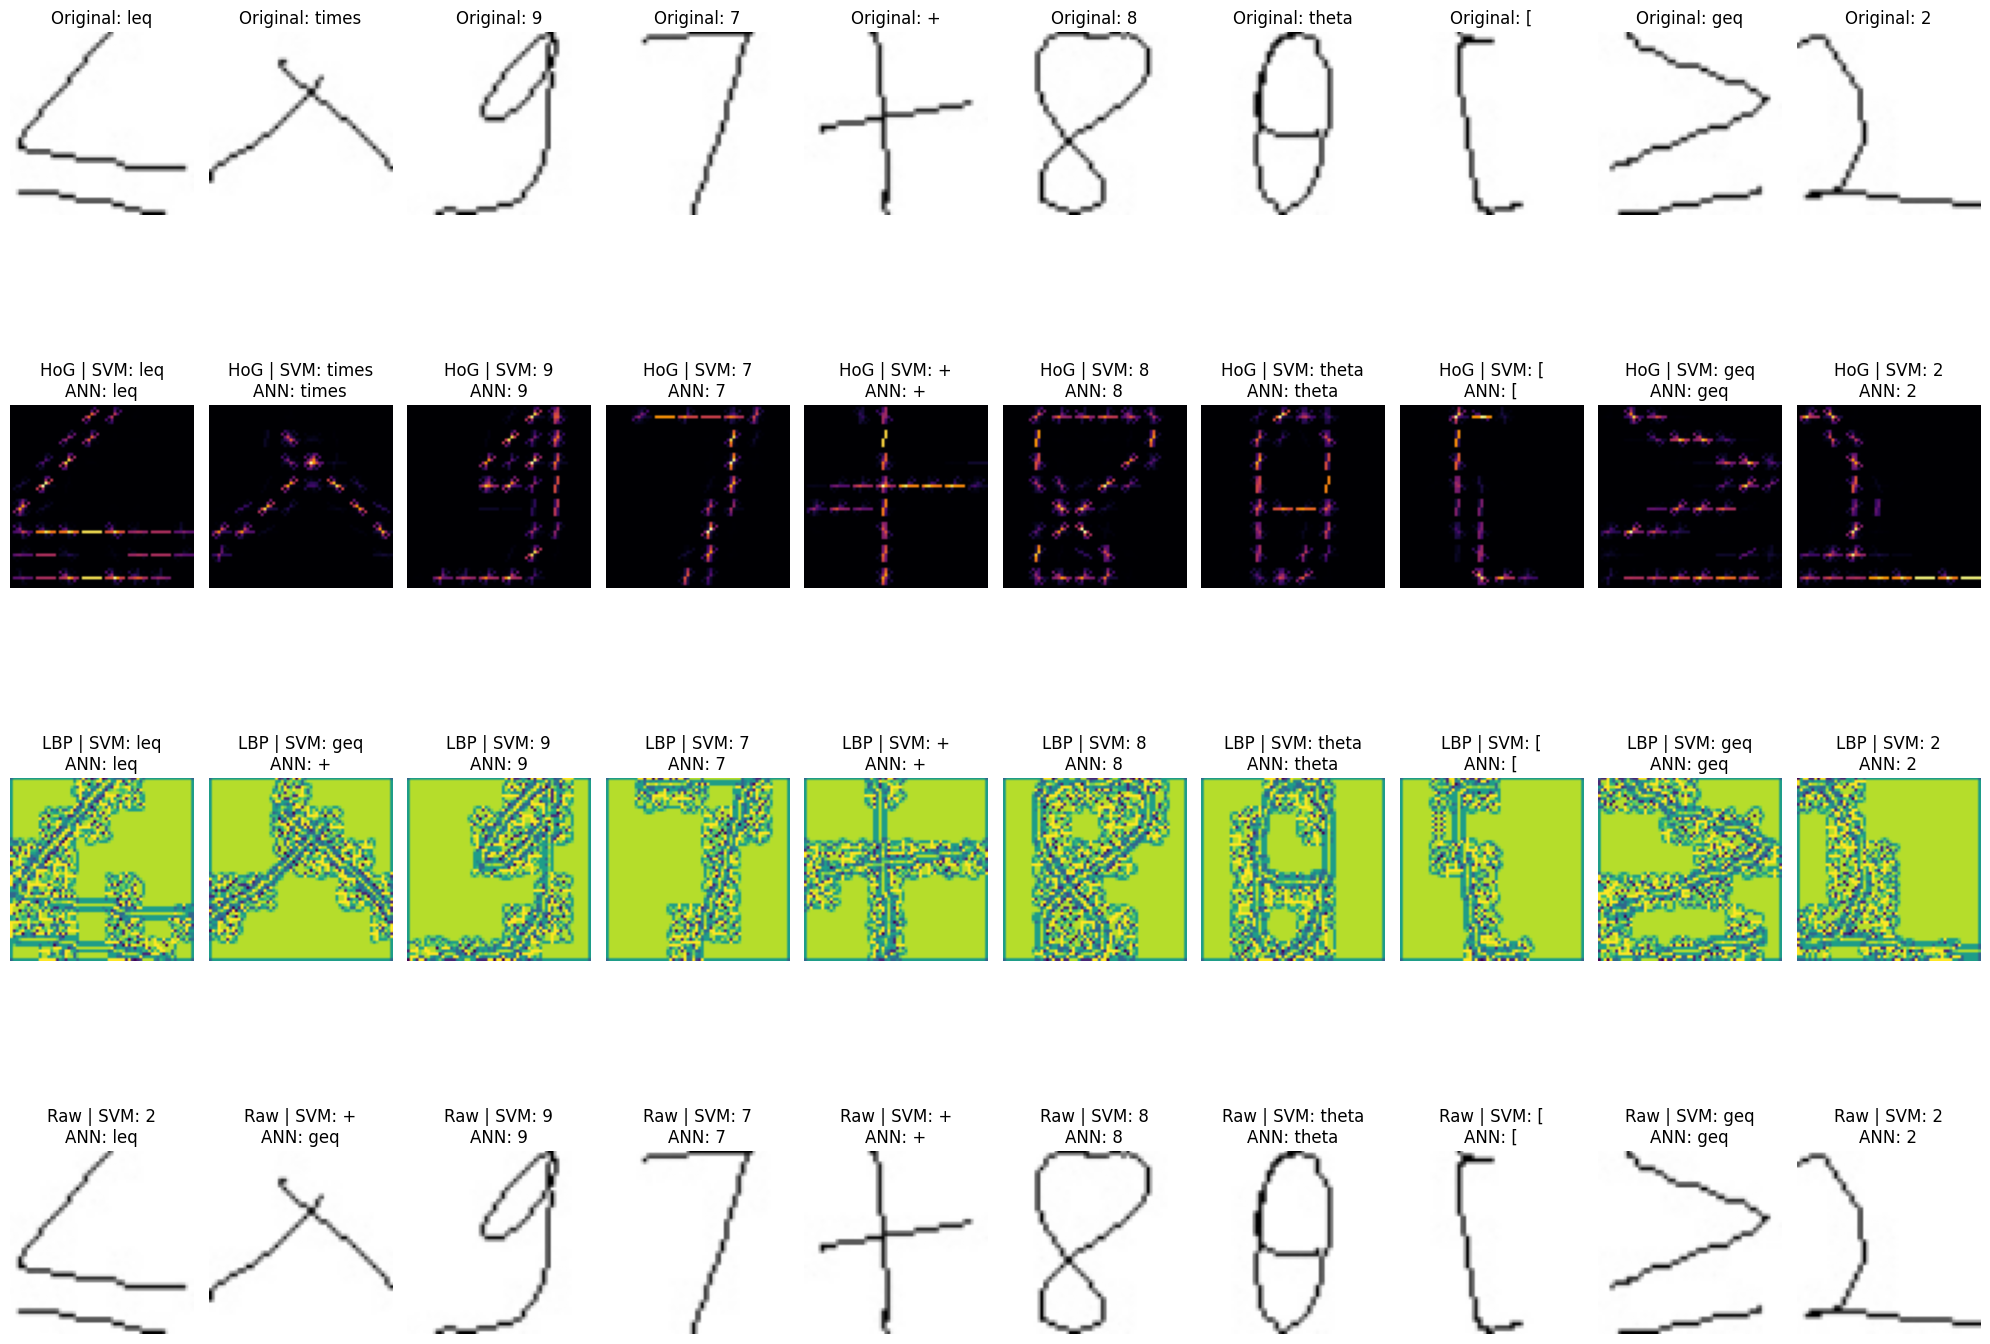

In [ ]:
# Ensure correct image and feature dimensions
image_size = int(np.sqrt(X_test.shape[1]))

# Selecting specific indices for each required label
labels = ['leq', 'times', '9', '7', '+', '8', 'theta', '[', 'geq', '2']
sample_indices = [np.where(y_test == le.transform([label])[0])[0][0] for label in labels]

fig, axes = plt.subplots(4, 10, figsize=(20, 16))

for j, idx in enumerate(sample_indices):
    original = X_test[idx].reshape(image_size, image_size)
    hog_features, hog_image = feature.hog(original, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True, block_norm="L2-Hys")
    lbp_image = feature.local_binary_pattern(original, P=8, R=1, method='uniform')

    axes[0, j].imshow(original, cmap='gray')
    axes[0, j].set_title(f"Original: {le.inverse_transform([y_test[idx]])[0]}")
    axes[0, j].axis('off')

    axes[1, j].imshow(hog_image, cmap='inferno')
    svm_hog_pred = svm_models['HoG'].predict(hog_features.reshape(1, -1))
    ann_hog_pred = ann_models['HoG'].predict(hog_features.reshape(1, -1).astype('float32'), verbose=0)
    axes[1, j].set_title(f"HoG | SVM: {le.inverse_transform(svm_hog_pred)[0]}\nANN: {le.inverse_transform([np.argmax(ann_hog_pred)])[0]}")
    axes[1, j].axis('off')

    axes[2, j].imshow(lbp_image, cmap='viridis')
    lbp_features = lbp_image.flatten()
    svm_lbp_pred = svm_models['LBP'].predict(lbp_features.reshape(1, -1))
    ann_lbp_pred = ann_models['LBP'].predict(lbp_features.reshape(1, -1).astype('float32'), verbose=0)
    axes[2, j].set_title(f"LBP | SVM: {le.inverse_transform(svm_lbp_pred)[0]}\nANN: {le.inverse_transform([np.argmax(ann_lbp_pred)])[0]}")
    axes[2, j].axis('off')

    axes[3, j].imshow(original, cmap='gray')
    svm_raw_pred = svm_models['Raw Pixels'].predict(X_test[idx].reshape(1, -1))
    ann_raw_pred = ann_models['Raw Pixels'].predict(X_test[idx].reshape(1, -1).astype('float32'), verbose=0)
    axes[3, j].set_title(f"Raw | SVM: {le.inverse_transform(svm_raw_pred)[0]}\nANN: {le.inverse_transform([np.argmax(ann_raw_pred)])[0]}")
    axes[3, j].axis('off')

plt.tight_layout()
plt.show()
